In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def generate_NN_functions(act_fn, act_fn_dif_a, act_fn_dif_b, neurons=3):
    # Method to evaluate the NN given x
    def NN(x, w):
        s = 0

        # Add linear combination of activation functions
        for i in range(neurons):
            s += w[i*3+2] * act_fn(w[i*3]*x + w[i*3+1])
        
        # Add bias term
        s += w[-1]

        return s

    # Generate MSE loss for the NN
    def loss(x, y, w):
        return ((y - NN(x, w))**2).sum()
    
    # Compute gradient of the loss function with respect to NN's weights
    def grad(x, y, w):
        if isinstance(x, np.ndarray):
            g = np.zeros((w.shape[0], x.shape[0]))
        else:
            g = np.zeros_like(w)
        
        for i in range(neurons):
            # Partial derivatives with respect to a_i
            g[i*3] = -2 * (y - NN(x, w)) * w[i*3+2] * act_fn_dif_a(w[i*3], w[i*3+1], x)

            # Partial derivatives with respect to b_i
            g[i*3+1] = -2 * (y - NN(x, w)) * w[i*3+2] * act_fn_dif_b(w[i*3], w[i*3+1], x)

            # Partial derivatives with respect to c_i
            g[i*3+2] = -2 * (y - NN(x, w)) * act_fn(w[i*3]*x + w[i*3+1])

        # Final partial derivative - with respect to bias term
        g[-1] = -2 * (y - NN(x, w))

        return g
    
    # Return the methods with respect to the neural network
    return NN, loss, grad

# Visualize loss
def visualize_loss(l_vect):
    plt.plot(np.arange(len(l_vect)), l_vect)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid (input is a linear transformation) with respect to a
def sig_dif_a(a, b, xi):
    return xi * sig_dif_b(a, b, xi)

# Derivative of sigmoid (input is a linear transformation) with respect to b
def sig_dif_b(a, b, xi):
    return np.exp(-a*xi - b) / ((1 + np.exp(-a*xi - b))**2)

In [13]:
NN, loss, grad = generate_NN_functions(sigmoid, sig_dif_a, sig_dif_b, 3)

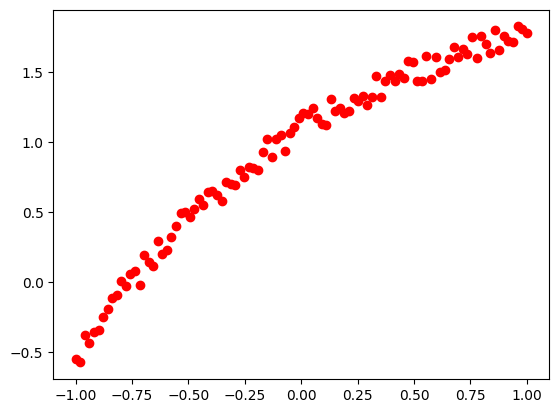

In [14]:
# Data to be trained on - let's have it fit to a noisy curve
np.random.seed(40)

f = lambda x: np.exp(x) - x**2
noise_scale = 0.2

x = np.linspace(-1, 1, 100)
y = f(x) + np.random.random(x.shape[0]) * noise_scale

plt.plot(x, y, "ro")
plt.show()

In [15]:
w_start = np.random.random(10)

In [16]:
# Adam Optimization
epochs = 500
batch_size = 4
lr = 0.001
beta_1 = 0.9
beta_2 = 0.999
l_vect = []

w = w_start.copy()

mean_moment = 0
var_moment = 0
t = 1
eps = 1e-8

for i in range(epochs):
    epoch_loss = 0
    
    # Stores an array of shuffled indices - useful for slicing
    shuffle = np.arange(len(x))
    np.random.shuffle(shuffle)

    num_batch = len(x) // batch_size
    if len(x) % batch_size != 0:
        num_batch += 1

    for b in range(num_batch):
        x_batch = x[shuffle][b*batch_size:(b+1)*batch_size]
        y_batch = y[shuffle][b*batch_size:(b+1)*batch_size]

        epoch_loss += loss(x_batch, y_batch, w)
        g = 1 / len(x_batch) * grad(x_batch, y_batch, w).sum(axis=1)

        mean_moment = beta_1 * mean_moment + (1-beta_1) * g
        var_moment = beta_2 * var_moment + (1-beta_2) * (g**2)

        corrected_mean = mean_moment / (1 - beta_1**t)
        corrected_var = var_moment / (1 - beta_2**t)

        w -= lr * corrected_mean / (np.sqrt(corrected_var) + eps)

        t += 1

    l_vect.append(epoch_loss)

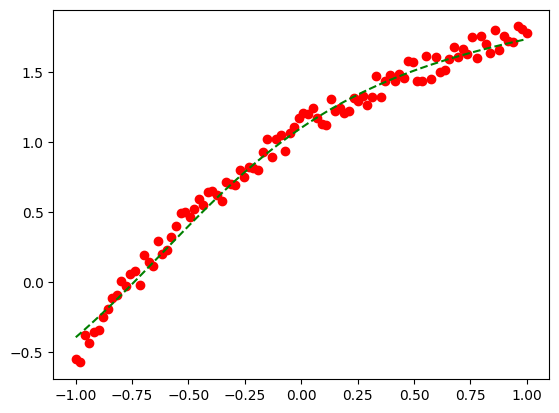

In [17]:
plt.plot(x, y, "ro", x, NN(x, w), "g--");